<a href="https://colab.research.google.com/github/AJPardhiv/ML-Lab/blob/main/Week_10_2420080001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

MARKET BASKET ANALYSIS

Total transactions: 10

Sample transactions:
Transaction 1: ['Bread', 'Milk', 'Eggs']
Transaction 2: ['Bread', 'Butter', 'Jam']
Transaction 3: ['Milk', 'Bread', 'Butter']

Binary matrix (first 5 rows):
   Bread  Butter  Cereal   Eggs    Jam   Milk
0   True   False   False   True  False   True
1   True    True   False  False   True  False
2   True    True   False  False  False   True
3   True    True   False   True  False   True
4  False   False    True   True  False   True

BASIC STATISTICS

Item frequencies:
Bread     8
Milk      8
Butter    6
Eggs      5
Jam       3
Cereal    2
dtype: int64

Average items per transaction: 3.20
Min items: 3
Max items: 4

APRIORI RESULTS

Frequent itemsets (support >= 0.3):
Total: 15
    support               itemsets
0       0.8                (Bread)
1       0.6               (Butter)
2       0.5                 (Eggs)
3       0.3                  (Jam)
4       0.8                 (Milk)
5       0.6        (Butter, Bread)
6   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

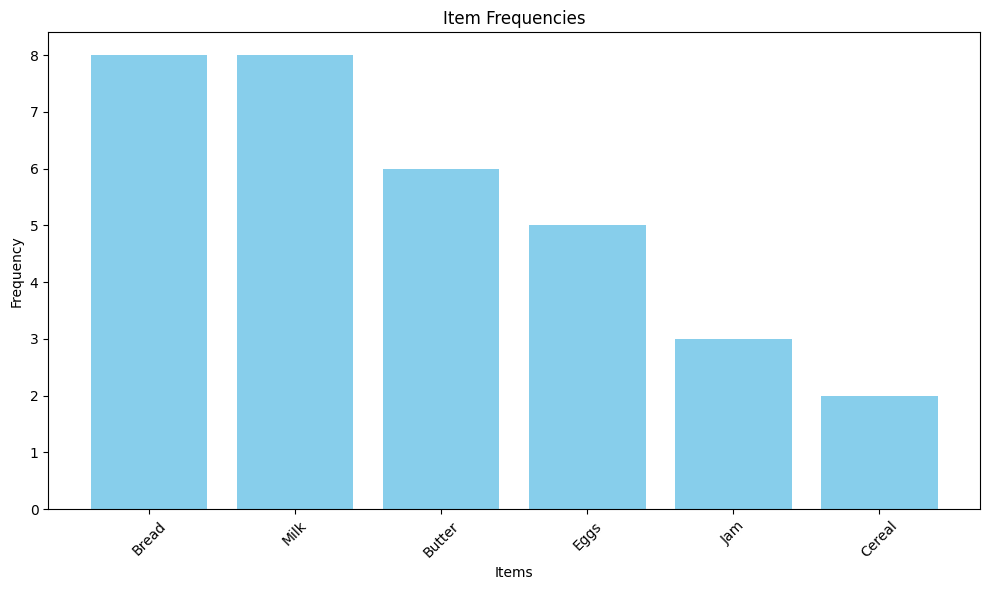

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

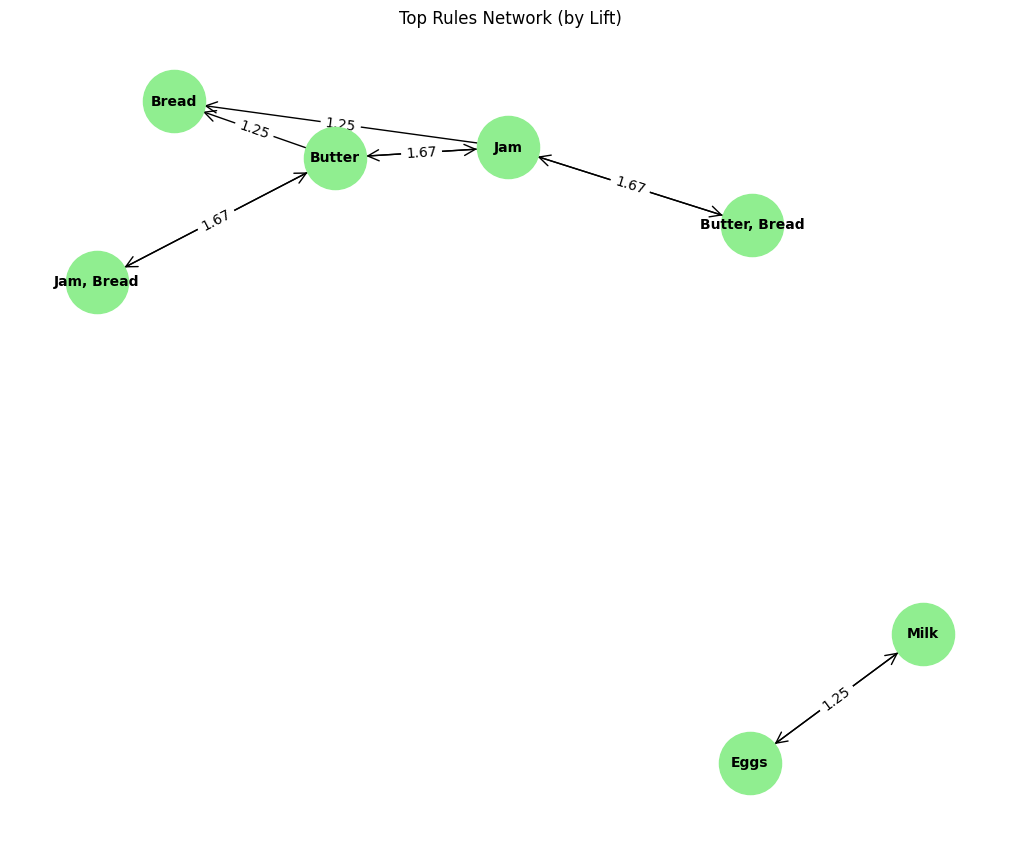


BUSINESS INTERPRETATION
Strongest association: Butter → Jam (Lift: 1.67)

Marketing Suggestions:
1. Place associated items close to each other in the store
2. Offer promotions or discounts on items frequently bought together
3. Encourage cross-selling using staff recommendations
4. Create themed product displays (e.g., breakfast combos, party packs)

Rules saved to 'market_basket_rules.csv'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx

# ===============================
# PART A: DATA PREPARATION
# ===============================
print("="*60)
print("MARKET BASKET ANALYSIS")
print("="*60)

# Sample transaction data (replace with your grocery dataset if needed)
transactions = [
    ['Bread', 'Milk', 'Eggs'],
    ['Bread', 'Butter', 'Jam'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Milk', 'Butter', 'Eggs'],
    ['Milk', 'Eggs', 'Cereal'],
    ['Bread', 'Eggs', 'Milk'],
    ['Butter', 'Jam', 'Bread'],
    ['Bread', 'Milk', 'Butter'],
    ['Milk', 'Cereal', 'Eggs'],
    ['Bread', 'Butter', 'Jam', 'Milk']
]

print(f"\nTotal transactions: {len(transactions)}")
print("\nSample transactions:")
for i in range(min(3, len(transactions))):
    print(f"Transaction {i+1}: {transactions[i]}")

# Convert transactions to binary matrix using TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print("\nBinary matrix (first 5 rows):")
print(df.head())

# Basic statistics
print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)

# Item frequencies
item_freq = df.sum().sort_values(ascending=False)
print("\nItem frequencies:")
print(item_freq)

# Transaction lengths
trans_lengths = [len(t) for t in transactions]
print(f"\nAverage items per transaction: {np.mean(trans_lengths):.2f}")
print(f"Min items: {min(trans_lengths)}")
print(f"Max items: {max(trans_lengths)}")

# ===============================
# PART B: APRIORI IMPLEMENTATION
# ===============================
print("\n" + "="*60)
print("APRIORI RESULTS")
print("="*60)

# Minimum support threshold
min_support = 0.3

# Find frequent itemsets
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
print(f"\nFrequent itemsets (support >= {min_support}):")
print(f"Total: {len(frequent_itemsets)}")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print(f"\nTotal association rules generated: {len(rules)}")

# Filter rules by confidence >= 0.5
rules = rules[rules['confidence'] >= 0.5]
print(f"Rules with confidence >= 0.5: {len(rules)}")

# ===============================
# PART C: ANALYSIS & INTERPRETATION
# ===============================
print("\n" + "="*60)
print("TOP RULES")
print("="*60)

# Top 10 by lift
print("\nTop 10 rules by lift:")
top_lift = rules.nlargest(10, 'lift')
for i, (idx, row) in enumerate(top_lift.iterrows(), 1):
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"{i}. {ante} → {cons}")
    print(f"   Support: {row['support']:.2f}, Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")

# Top 10 by confidence
print("\nTop 10 rules by confidence:")
top_conf = rules.nlargest(10, 'confidence')
for i, (idx, row) in enumerate(top_conf.iterrows(), 1):
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"{i}. {ante} → {cons}")
    print(f"   Support: {row['support']:.2f}, Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")

# Visualization: Item Frequencies
plt.figure(figsize=(10, 6))
plt.bar(range(len(item_freq)), item_freq.values, color='skyblue')
plt.xticks(range(len(item_freq)), item_freq.index, rotation=45)
plt.title('Item Frequencies')
plt.xlabel('Items')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Visualization: Network of top rules by lift
if len(rules) > 0:
    plt.figure(figsize=(10, 8))
    G = nx.DiGraph()

    for idx, row in top_lift.iterrows():
        ante = ', '.join(list(row['antecedents']))
        cons = ', '.join(list(row['consequents']))
        G.add_edge(ante, cons, weight=row['lift'])

    pos = nx.spring_layout(G, k=1)
    nx.draw(G, pos, with_labels=True, node_color='lightgreen',
            node_size=2000, font_size=10, font_weight='bold',
            arrows=True, arrowstyle='->', arrowsize=20)

    # Edge labels
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title('Top Rules Network (by Lift)')
    plt.show()

# Business Interpretation
print("\n" + "="*60)
print("BUSINESS INTERPRETATION")
print("="*60)

if len(rules) > 0:
    best_rule = rules.nlargest(1, 'lift').iloc[0]
    ante = ', '.join(list(best_rule['antecedents']))
    cons = ', '.join(list(best_rule['consequents']))
    print(f"Strongest association: {ante} → {cons} (Lift: {best_rule['lift']:.2f})")

print("\nMarketing Suggestions:")
print("1. Place associated items close to each other in the store")
print("2. Offer promotions or discounts on items frequently bought together")
print("3. Encourage cross-selling using staff recommendations")
print("4. Create themed product displays (e.g., breakfast combos, party packs)")

# Save rules to CSV
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_csv('market_basket_rules.csv', index=False)
print("\nRules saved to 'market_basket_rules.csv'")

**POST LAB**

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

MARKET BASKET ANALYSIS - POST LAB
Total transactions: 10


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

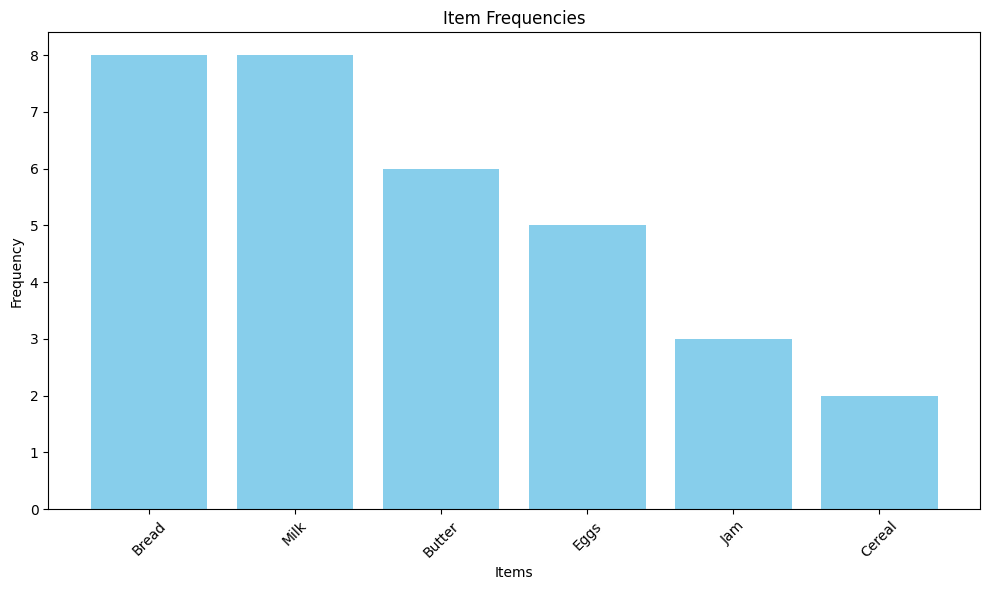

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Support Threshold: 0.2
Apriori: 19 frequent itemsets, 32 rules
FP-Growth: 19 frequent itemsets, 32 rules

Support Threshold: 0.3
Apriori: 15 frequent itemsets, 22 rules
FP-Growth: 15 frequent itemsets, 22 rules

Support Threshold: 0.5
Apriori: 7 frequent itemsets, 4 rules
FP-Growth: 7 frequent itemsets, 4 rules

Pruned Rules (Support=0.3, Confidence>=0.6, Lift>=1.1, max 2 items): 13

Online Courses Dataset - Rules:
          antecedents         consequents  support  confidence      lift
0               (SQL)      (Data Science)      0.6    1.000000  1.250000
1      (Data Science)               (SQL)      0.6    0.750000  1.250000
2            (Python)  (Machine Learning)      0.4    0.666667  1.666667
3  (Machine Learning)            (Python)      0.4    1.000000  1.666667
MARKET BASKET ANALYSIS - POST LAB
Total transactions: 10


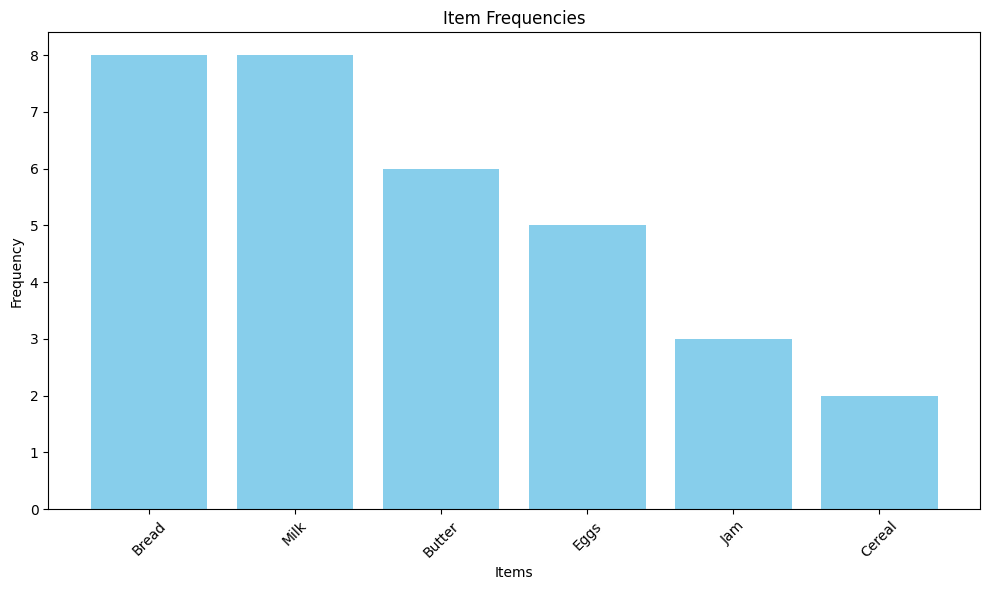


Support Threshold: 0.2
Apriori: 19 frequent itemsets, 32 rules
FP-Growth: 19 frequent itemsets, 32 rules

Support Threshold: 0.3
Apriori: 15 frequent itemsets, 22 rules
FP-Growth: 15 frequent itemsets, 22 rules

Support Threshold: 0.5
Apriori: 7 frequent itemsets, 4 rules
FP-Growth: 7 frequent itemsets, 4 rules

Pruned Rules (Support=0.3, Confidence>=0.6, Lift>=1.1, max 2 items): 13

Online Courses Dataset - Rules:
          antecedents         consequents  support  confidence      lift
0               (SQL)      (Data Science)      0.6    1.000000  1.250000
1      (Data Science)               (SQL)      0.6    0.750000  1.250000
2            (Python)  (Machine Learning)      0.4    0.666667  1.666667
3  (Machine Learning)            (Python)      0.4    1.000000  1.666667


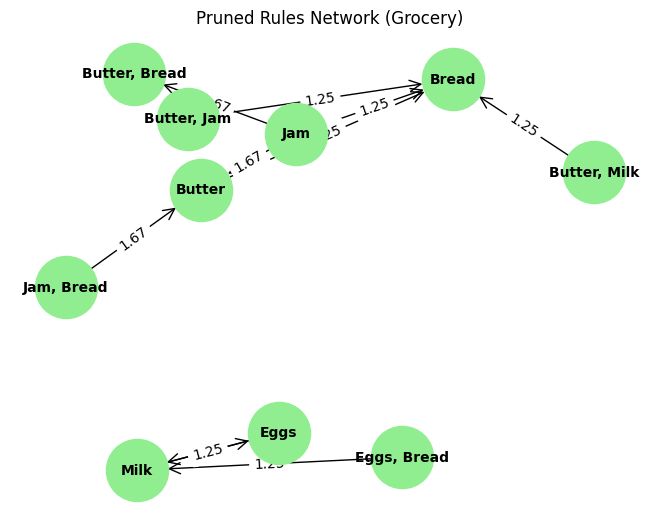


BUSINESS INTERPRETATION
Strongest association: Jam → Butter (Lift: 1.67)

Marketing Suggestions (India-friendly):
1. Place associated items near each other in the store (e.g., bread & butter).
2. Offer combo discounts during festivals or breakfast promotions.
3. Cross-sell using staff suggestions or app notifications.
4. Create thematic sections (breakfast, snacks, or festive combos).

Pruned rules saved to 'postlab_pruned_rules.csv'


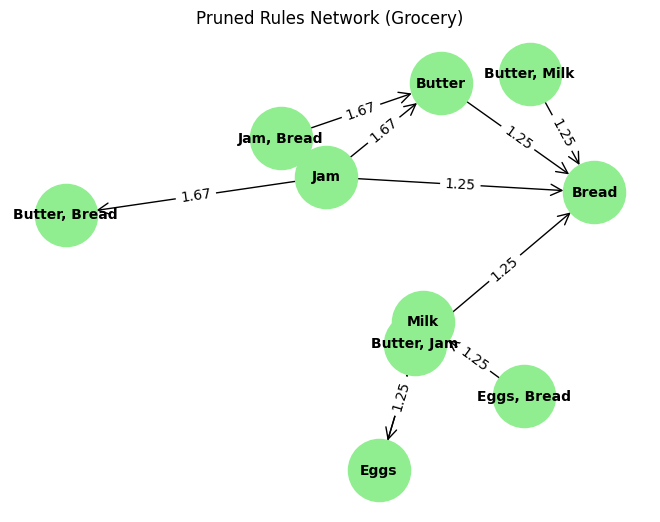


Pruned rules saved to 'postlab_pruned_rules.csv'


In [4]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx

# ===============================
# PART A: DATA PREPARATION
# ===============================
print("="*60)
print("MARKET BASKET ANALYSIS - POST LAB")
print("="*60)

# Sample transaction data (can be replaced with real datasets)
transactions = [
    ['Bread', 'Milk', 'Eggs'],
    ['Bread', 'Butter', 'Jam'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Milk', 'Butter', 'Eggs'],
    ['Milk', 'Eggs', 'Cereal'],
    ['Bread', 'Eggs', 'Milk'],
    ['Butter', 'Jam', 'Bread'],
    ['Bread', 'Milk', 'Butter'],
    ['Milk', 'Cereal', 'Eggs'],
    ['Bread', 'Butter', 'Jam', 'Milk']
]

print(f"Total transactions: {len(transactions)}")

# Transaction Encoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Item frequencies
item_freq = df.sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(range(len(item_freq)), item_freq.values, color='skyblue')
plt.xticks(range(len(item_freq)), item_freq.index, rotation=45)
plt.title('Item Frequencies')
plt.xlabel('Items')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ===============================
# PART B: APRIORI & FP-GROWTH
# ===============================
min_supports = [0.2, 0.3, 0.5]  # Different thresholds

apriori_results = {}
fpgrowth_results = {}

for sup in min_supports:
    # Apriori
    apr_sets = apriori(df, min_support=sup, use_colnames=True)
    apr_rules = association_rules(apr_sets, metric='lift', min_threshold=1)
    apriori_results[sup] = apr_rules

    # FP-Growth
    fp_sets = fpgrowth(df, min_support=sup, use_colnames=True)
    fp_rules = association_rules(fp_sets, metric='lift', min_threshold=1)
    fpgrowth_results[sup] = fp_rules

    print(f"\nSupport Threshold: {sup}")
    print(f"Apriori: {len(apr_sets)} frequent itemsets, {len(apr_rules)} rules")
    print(f"FP-Growth: {len(fp_sets)} frequent itemsets, {len(fp_rules)} rules")

# ===============================
# PART C: RULE PRUNING
# ===============================
# Pruning by confidence, lift, and length
def prune_rules(rules, min_conf=0.5, min_lift=1.2, max_len=None):
    pruned = rules[rules['confidence'] >= min_conf]
    pruned = pruned[pruned['lift'] >= min_lift]
    if max_len:
        pruned = pruned[pruned['antecedents'].apply(lambda x: len(x) <= max_len)]
    return pruned

pruned_rules = prune_rules(apriori_results[0.3], min_conf=0.6, min_lift=1.1, max_len=2)
print(f"\nPruned Rules (Support=0.3, Confidence>=0.6, Lift>=1.1, max 2 items): {len(pruned_rules)}")

# ===============================
# PART D: APPLY TO DIFFERENT DOMAINS
# ===============================
# Example: Online courses dataset
online_courses = [
    ['Python', 'Data Science', 'SQL'],
    ['Python', 'Machine Learning'],
    ['SQL', 'Data Science'],
    ['Python', 'Data Science', 'Machine Learning'],
    ['Data Science', 'SQL'],
]

te2 = TransactionEncoder()
te2_ary = te2.fit(online_courses).transform(online_courses)
df_courses = pd.DataFrame(te2_ary, columns=te2.columns_)

fp_sets_courses = fpgrowth(df_courses, min_support=0.4, use_colnames=True)
fp_rules_courses = association_rules(fp_sets_courses, metric='lift', min_threshold=1.0)
print(f"\nOnline Courses Dataset - Rules:")
print(fp_rules_courses[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# ===============================
# PART E: VISUALIZATION DASHBOARD
# ===============================
def visualize_rules(rules, top_n=10, title='Association Rules Network'):
    if len(rules) == 0:
        print("No rules to visualize.")
        return

    top_rules = rules.nlargest(top_n, 'lift')
    G = nx.DiGraph()

    for idx, row in top_rules.iterrows():
        ante = ', '.join(list(row['antecedents']))
        cons = ', '.join(list(row['consequents']))
        G.add_edge(ante, cons, weight=row['lift'])

    pos = nx.spring_layout(G, k=1)
    nx.draw(G, pos, with_labels=True, node_color='lightgreen',
            node_size=2000, font_size=10, font_weight='bold',
            arrows=True, arrowstyle='->', arrowsize=20)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title(title)
    plt.show()
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx

# ===============================
# PART A: DATA PREPARATION
# ===============================
print("="*60)
print("MARKET BASKET ANALYSIS - POST LAB")
print("="*60)

# Sample grocery transaction data (replace with real dataset)
transactions = [
    ['Bread', 'Milk', 'Eggs'],
    ['Bread', 'Butter', 'Jam'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Milk', 'Butter', 'Eggs'],
    ['Milk', 'Eggs', 'Cereal'],
    ['Bread', 'Eggs', 'Milk'],
    ['Butter', 'Jam', 'Bread'],
    ['Bread', 'Milk', 'Butter'],
    ['Milk', 'Cereal', 'Eggs'],
    ['Bread', 'Butter', 'Jam', 'Milk']
]

print(f"Total transactions: {len(transactions)}")

# Transaction Encoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Item frequencies plot
item_freq = df.sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(range(len(item_freq)), item_freq.values, color='skyblue')
plt.xticks(range(len(item_freq)), item_freq.index, rotation=45)
plt.title('Item Frequencies')
plt.xlabel('Items')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ===============================
# PART B: APRIORI & FP-GROWTH
# ===============================
min_supports = [0.2, 0.3, 0.5]  # Different thresholds
apriori_results = {}
fpgrowth_results = {}

for sup in min_supports:
    # Apriori
    apr_sets = apriori(df, min_support=sup, use_colnames=True)
    apr_rules = association_rules(apr_sets, metric='lift', min_threshold=1)
    apriori_results[sup] = apr_rules

    # FP-Growth
    fp_sets = fpgrowth(df, min_support=sup, use_colnames=True)
    fp_rules = association_rules(fp_sets, metric='lift', min_threshold=1)
    fpgrowth_results[sup] = fp_rules

    print(f"\nSupport Threshold: {sup}")
    print(f"Apriori: {len(apr_sets)} frequent itemsets, {len(apr_rules)} rules")
    print(f"FP-Growth: {len(fp_sets)} frequent itemsets, {len(fp_rules)} rules")

# ===============================
# PART C: RULE PRUNING
# ===============================
def prune_rules(rules, min_conf=0.5, min_lift=1.2, max_len=None):
    pruned = rules[rules['confidence'] >= min_conf]
    pruned = pruned[pruned['lift'] >= min_lift]
    if max_len:
        pruned = pruned[pruned['antecedents'].apply(lambda x: len(x) <= max_len)]
    return pruned

pruned_rules = prune_rules(apriori_results[0.3], min_conf=0.6, min_lift=1.1, max_len=2)
print(f"\nPruned Rules (Support=0.3, Confidence>=0.6, Lift>=1.1, max 2 items): {len(pruned_rules)}")

# ===============================
# PART D: APPLY TO DIFFERENT DOMAINS
# ===============================
# Example: Online courses dataset
online_courses = [
    ['Python', 'Data Science', 'SQL'],
    ['Python', 'Machine Learning'],
    ['SQL', 'Data Science'],
    ['Python', 'Data Science', 'Machine Learning'],
    ['Data Science', 'SQL'],
]

te2 = TransactionEncoder()
te2_ary = te2.fit(online_courses).transform(online_courses)
df_courses = pd.DataFrame(te2_ary, columns=te2.columns_)

fp_sets_courses = fpgrowth(df_courses, min_support=0.4, use_colnames=True)
fp_rules_courses = association_rules(fp_sets_courses, metric='lift', min_threshold=1.0)
print(f"\nOnline Courses Dataset - Rules:")
print(fp_rules_courses[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# ===============================
# PART E: VISUALIZATION DASHBOARD
# ===============================
def visualize_rules(rules, top_n=10, title='Association Rules Network'):
    if len(rules) == 0:
        print("No rules to visualize.")
        return

    top_rules = rules.nlargest(top_n, 'lift')
    G = nx.DiGraph()

    for idx, row in top_rules.iterrows():
        ante = ', '.join(list(row['antecedents']))
        cons = ', '.join(list(row['consequents']))
        G.add_edge(ante, cons, weight=row['lift'])

    pos = nx.spring_layout(G, k=1)
    nx.draw(G, pos, with_labels=True, node_color='lightgreen',
            node_size=2000, font_size=10, font_weight='bold',
            arrows=True, arrowstyle='->', arrowsize=20)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title(title)
    plt.show()

visualize_rules(pruned_rules, top_n=10, title='Pruned Rules Network (Grocery)')

# ===============================
# PART F: BUSINESS INTERPRETATION
# ===============================
print("\n" + "="*60)
print("BUSINESS INTERPRETATION")
print("="*60)

if len(pruned_rules) > 0:
    best_rule = pruned_rules.nlargest(1, 'lift').iloc[0]
    ante = ', '.join(list(best_rule['antecedents']))
    cons = ', '.join(list(best_rule['consequents']))
    print(f"Strongest association: {ante} → {cons} (Lift: {best_rule['lift']:.2f})")

print("\nMarketing Suggestions (India-friendly):")
print("1. Place associated items near each other in the store (e.g., bread & butter).")
print("2. Offer combo discounts during festivals or breakfast promotions.")
print("3. Cross-sell using staff suggestions or app notifications.")
print("4. Create thematic sections (breakfast, snacks, or festive combos).")

# ===============================
# SAVE RESULTS
# ===============================
pruned_rules.to_csv('postlab_pruned_rules.csv', index=False)
print("\nPruned rules saved to 'postlab_pruned_rules.csv'")

# Visualize pruned rules
visualize_rules(pruned_rules, top_n=10, title='Pruned Rules Network (Grocery)')

# ===============================
# SAVE RESULTS
# ===============================
pruned_rules.to_csv('postlab_pruned_rules.csv', index=False)
print("\nPruned rules saved to 'postlab_pruned_rules.csv'")